# Test Rapide GO/NO-GO - Validation Approche Modélisation

**Objectif :** Valider que les features disponibles (Cluster climatique, Culture, Fertilizer_proxy, Irrigation_proxy) permettent d'obtenir des performances acceptables (R² > 0.70) avant d'investir du temps dans l'optimisation complète.

**Stratégie :** Tester 4 modèles avec hyperparamètres par défaut sur la culture Rice uniquement. Si les résultats sont prometteurs, on continue avec toutes les cultures et le tuning des hyperparamètres. Sinon, on revoit la stratégie de features ou les proxys créés.

**Décision :** GO si R² > 0.70 | ANALYSER si 0.50-0.70 | NO-GO si < 0.50

## Imports et configuration

In [149]:
# === IMPORTS STANDARDS ===
import pandas as pd
import numpy as np
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# === SKLEARN - PREPROCESSING ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# === SKLEARN - MODÈLES ===
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# === XGBOOST ===
import xgboost as xgb

# === SKLEARN - MÉTRIQUES ===
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# === FEATURE IMPORTANCE ===
from sklearn.metrics import accuracy_score

# === MLFLOW ===
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# === CONFIGURATION PROJET ===
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from config.paths import DONNEES_AGRO_CLIMATIQUES
from config.paths import DONNEES_PROCESSED
from config.paths import DONNEES_HISTORIQUES
from config.config import RANDOM_STATE

# === CONFIGURATION AFFICHAGE ===
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('default')

## Chargement dataset et split et préparation des données 

### Chargement dataset

In [3]:
df = pd.read_csv(DONNEES_PROCESSED / "dataset_modelisation_v1.csv")

In [4]:
df.head()

,Area,Area_Code,Item,Year,yield_hg_per_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp_old,avg_temp,Fertilizer_proxy,Irrigation_proxy,Cluster_climat,Cluster_label
0,Albania,3,Maize,1990,36613,1485.0,121.0,16.37,16.37,0,0,0,Tempéré
1,Albania,3,Potatoes,1990,66667,1485.0,121.0,16.37,16.37,0,0,0,Tempéré
2,Albania,3,"Rice, paddy",1990,23333,1485.0,121.0,16.37,16.37,0,0,0,Tempéré
3,Albania,3,Sorghum,1990,12500,1485.0,121.0,16.37,16.37,0,0,0,Tempéré
4,Albania,3,Soybeans,1990,7000,1485.0,121.0,16.37,16.37,0,0,0,Tempéré


In [5]:
df_rice = df[df['Item'] == 'Rice, paddy'].copy()

In [6]:
print(f"✅ Dataset Rice créé : {df_rice.shape[0]} lignes sur {df.shape[0]} total")
print(f"📊 Période : {df_rice['Year'].min()} - {df_rice['Year'].max()}")
print(f"🌍 Nombre de pays : {df_rice['Area'].nunique()}")

✅ Dataset Rice créé : 3388 lignes sur 28242 total
📊 Période : 1990 - 2013
🌍 Nombre de pays : 68


In [7]:
df_rice.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3388 entries, 2 to 28237
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           3388 non-null   object 
 1   Area_Code                      3388 non-null   int64  
 2   Item                           3388 non-null   object 
 3   Year                           3388 non-null   int64  
 4   yield_hg_per_ha                3388 non-null   int64  
 5   average_rain_fall_mm_per_year  3388 non-null   float64
 6   pesticides_tonnes              3388 non-null   float64
 7   avg_temp_old                   3388 non-null   float64
 8   avg_temp                       3388 non-null   float64
 9   Fertilizer_proxy               3388 non-null   int64  
 10  Irrigation_proxy               3388 non-null   int64  
 11  Cluster_climat                 3388 non-null   int64  
 12  Cluster_label                  3388 non-null   objec

## Test des modèles

### PLAN A : Modèle uniquement sur Fertilizer et Irrigation proxys et cluster climat

In [8]:
# Feature + target
X = df_rice[['Fertilizer_proxy', 'Irrigation_proxy', 'Cluster_climat']]
y = df_rice['yield_hg_per_ha']

In [9]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=RANDOM_STATE)

In [10]:
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBRegressor(random_state=RANDOM_STATE)
}

In [11]:
results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({  
        'Model': model_name,
        'R²': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    })


In [12]:
print(results)

[{'Model': 'LinearRegression', 'R²': 0.20646695796782388, 'MAE': 13998.904021670729, 'RMSE': np.float64(17567.373614115484)}, {'Model': 'RandomForest', 'R²': 0.23182947894501282, 'MAE': 13066.782026402985, 'RMSE': np.float64(17284.35384624206)}, {'Model': 'GradientBoosting', 'R²': 0.2327100743609909, 'MAE': 13079.362630676247, 'RMSE': np.float64(17274.444010550007)}, {'Model': 'XGBoost', 'R²': 0.2317967414855957, 'MAE': 13073.705078125, 'RMSE': np.float64(17284.72250283469)}]


### PLAN B.1 : Modèle average_rainfall, avg_temp, Fertilizer_input, Irrigation_input, Item_encoded

In [13]:
df_rice.columns

Index(['Area', 'Area_Code', 'Item', 'Year', 'yield_hg_per_ha',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp_old',
       'avg_temp', 'Fertilizer_proxy', 'Irrigation_proxy', 'Cluster_climat',
       'Cluster_label'],
      dtype='object')

In [14]:
# Feature + target
X = df_rice[['average_rain_fall_mm_per_year', 'avg_temp', 'Fertilizer_proxy', 'Irrigation_proxy']]
y = df_rice['yield_hg_per_ha']

In [15]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=RANDOM_STATE)

In [16]:
# Séparer features continues et binaires
features_continues = ['average_rain_fall_mm_per_year', 'avg_temp']
features_binaires = ['Fertilizer_proxy', 'Irrigation_proxy']

# Standardiser uniquement les continues
scaler = StandardScaler()
X_continues_scaled = scaler.fit_transform(X_train[features_continues])
X_test_continues_scaled = scaler.transform(X_test[features_continues])

# Recombiner
X_train_final = np.hstack([X_continues_scaled, X_train[features_binaires].values])
X_test_final = np.hstack([X_test_continues_scaled, X_test[features_binaires].values])

In [17]:
results = []

for model_name, model in models.items():
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)
    results.append({  
        'Model': model_name,
        'R²': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    })


In [18]:
print(results)

[{'Model': 'LinearRegression', 'R²': 0.2783830454294033, 'MAE': 12497.173400722999, 'RMSE': np.float64(16752.42546901788)}, {'Model': 'RandomForest', 'R²': 0.926153602347338, 'MAE': 2778.3710248860234, 'RMSE': np.float64(5359.064541662169)}, {'Model': 'GradientBoosting', 'R²': 0.8425845421370866, 'MAE': 5622.259682485697, 'RMSE': np.float64(7824.3454871222075)}, {'Model': 'XGBoost', 'R²': 0.9194998741149902, 'MAE': 3335.23681640625, 'RMSE': np.float64(5595.289268661631)}]


### PLAN B.2 : Ajout de Pesticides

In [19]:
df_rice.columns

Index(['Area', 'Area_Code', 'Item', 'Year', 'yield_hg_per_ha',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp_old',
       'avg_temp', 'Fertilizer_proxy', 'Irrigation_proxy', 'Cluster_climat',
       'Cluster_label'],
      dtype='object')

In [20]:
# Feature + target
X = df_rice[['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'Fertilizer_proxy', 'Irrigation_proxy']]
y = df_rice['yield_hg_per_ha']

In [21]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=RANDOM_STATE)

In [22]:
# Séparer features continues et binaires
features_continues = ['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
features_binaires = ['Fertilizer_proxy', 'Irrigation_proxy']

# Standardiser uniquement les continues
scaler = StandardScaler()
X_continues_scaled = scaler.fit_transform(X_train[features_continues])
X_test_continues_scaled = scaler.transform(X_test[features_continues])

# Recombiner
X_train_final = np.hstack([X_continues_scaled, X_train[features_binaires].values])
X_test_final = np.hstack([X_test_continues_scaled, X_test[features_binaires].values])

In [23]:
results = []

for model_name, model in models.items():
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)
    results.append({  
        'Model': model_name,
        'R²': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    })


In [24]:
results = []
for model_name, model in models.items():
    model.fit(X_train_final, y_train)
    
    # Prédictions train et test
    y_pred_train = model.predict(X_train_final)
    y_pred_test = model.predict(X_test_final)
    
    # Métriques
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    ecart = r2_train - r2_test
    
    # Affichage
    print(f"\n{model_name}:")
    print(f"  R² train: {r2_train:.3f}")
    print(f"  R² test:  {r2_test:.3f}")
    print(f"  Écart:    {ecart:.3f} {'✅' if ecart < 0.05 else '⚠️' if ecart < 0.15 else '🔴'}")
    
    results.append({  
        'Model': model_name,
        'R²_train': r2_train,
        'R²_test': r2_test,
        'Écart': ecart,
        'MAE': mean_absolute_error(y_test, y_pred_test),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test))
    })

df_results = pd.DataFrame(results)
print("\n" + "="*50)
print(df_results)


LinearRegression:
  R² train: 0.265
  R² test:  0.279
  Écart:    -0.014 ✅

RandomForest:
  R² train: 0.991
  R² test:  0.946
  Écart:    0.045 ✅

GradientBoosting:
  R² train: 0.869
  R² test:  0.863
  Écart:    0.006 ✅

XGBoost:
  R² train: 0.987
  R² test:  0.943
  Écart:    0.045 ✅

              Model  R²_train   R²_test     Écart           MAE          RMSE
0  LinearRegression  0.264986  0.279223 -0.014237  12522.827714  16742.671605
1      RandomForest  0.990824  0.946178  0.044646   2208.492311   4575.128397
2  GradientBoosting  0.868745  0.862939  0.005806   5158.035643   7300.988938
3           XGBoost  0.987185  0.942656  0.044529   2514.665283   4722.470116


### PLAN B.3 : Valeurs continues seulement

In [25]:
df_rice.columns

Index(['Area', 'Area_Code', 'Item', 'Year', 'yield_hg_per_ha',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp_old',
       'avg_temp', 'Fertilizer_proxy', 'Irrigation_proxy', 'Cluster_climat',
       'Cluster_label'],
      dtype='object')

In [26]:
# Feature + target
X = df_rice[['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']]
y = df_rice['yield_hg_per_ha']

In [27]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=RANDOM_STATE)

In [28]:
# Features continues uniquement (pas de binaires)
features_continues = ['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

# Standardiser directement
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train[features_continues])
X_test_final = scaler.transform(X_test[features_continues])

In [29]:
results = []

for model_name, model in models.items():
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)
    results.append({  
        'Model': model_name,
        'R²': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    })


In [30]:
results = []
for model_name, model in models.items():
    model.fit(X_train_final, y_train)
    
    # Prédictions train et test
    y_pred_train = model.predict(X_train_final)
    y_pred_test = model.predict(X_test_final)
    
    # Métriques
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    ecart = r2_train - r2_test
    
    # Affichage
    print(f"\n{model_name}:")
    print(f"  R² train: {r2_train:.3f}")
    print(f"  R² test:  {r2_test:.3f}")
    print(f"  Écart:    {ecart:.3f} {'✅' if ecart < 0.05 else '⚠️' if ecart < 0.15 else '🔴'}")
    
    results.append({  
        'Model': model_name,
        'R²_train': r2_train,
        'R²_test': r2_test,
        'Écart': ecart,
        'MAE': mean_absolute_error(y_test, y_pred_test),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test))
    })

df_results = pd.DataFrame(results)
print("\n" + "="*50)
print(df_results)


LinearRegression:
  R² train: 0.173
  R² test:  0.181
  Écart:    -0.007 ✅

RandomForest:
  R² train: 0.991
  R² test:  0.946
  Écart:    0.045 ✅

GradientBoosting:
  R² train: 0.869
  R² test:  0.863
  Écart:    0.006 ✅

XGBoost:
  R² train: 0.987
  R² test:  0.943
  Écart:    0.045 ✅

              Model  R²_train   R²_test     Écart           MAE          RMSE
0  LinearRegression  0.173348  0.180539 -0.007191  13384.497783  17852.064396
1      RandomForest  0.990856  0.946103  0.044753   2211.770932   4578.323511
2  GradientBoosting  0.868745  0.862939  0.005806   5158.035643   7300.988938
3           XGBoost  0.987185  0.942656  0.044529   2514.665283   4722.470116


In [31]:
print(results)

[{'Model': 'LinearRegression', 'R²_train': 0.1733476380273241, 'R²_test': 0.18053911366309638, 'Écart': -0.007191475635772271, 'MAE': 13384.497782943425, 'RMSE': np.float64(17852.064395506444)}, {'Model': 'RandomForest', 'R²_train': 0.9908562069993223, 'R²_test': 0.9461030369954785, 'Écart': 0.04475317000384382, 'MAE': 2211.770931643784, 'RMSE': np.float64(4578.323510786829)}, {'Model': 'GradientBoosting', 'R²_train': 0.8687445380462364, 'R²_test': 0.862938739836068, 'Écart': 0.005805798210168467, 'MAE': 5158.035642740667, 'RMSE': np.float64(7300.988938118633)}, {'Model': 'XGBoost', 'R²_train': 0.9871850609779358, 'R²_test': 0.9426557421684265, 'Écart': 0.04452931880950928, 'MAE': 2514.665283203125, 'RMSE': np.float64(4722.470116369187)}]


### PLAN B4 : Toutes les cultures

In [32]:
df['Item'].unique()

array(['Maize', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Wheat',
       'Cassava', 'Sweet potatoes', 'Plantains and others', 'Yams'],
      dtype=object)

In [33]:
cultures_test = ['Rice, paddy', 'Maize', 'Wheat', 'Soybeans']

In [34]:
print(models) 

{'LinearRegression': LinearRegression(), 'RandomForest': RandomForestRegressor(random_state=54), 'GradientBoosting': GradientBoostingRegressor(random_state=54), 'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)}


In [77]:
cultures_test = ['Maize', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Wheat',
       'Cassava', 'Sweet potatoes', 'Plantains and others', 'Yams']

results = []
for culture in cultures_test:
    print("\n" + "="*50)
    print(f"CULTURE : {culture}")
    print("="*50)
    
    # Filtrer culture
    df_culture = df[df['Item'] == culture].copy()
    
    # Features + Target
    X = df_culture[['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']]
    y = df_culture['yield_hg_per_ha']
    
    # Split ← AJOUTÉ !
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )
    
    # Standardiser
    scaler = StandardScaler()
    X_train_final = scaler.fit_transform(X_train)
    X_test_final = scaler.transform(X_test)
    
    # Tester modèles
    
    for model_name, model in models.items():  # ← CORRIGÉ : .items()
        model.fit(X_train_final, y_train)
        
        # Prédictions
        y_pred_train = model.predict(X_train_final)
        y_pred_test = model.predict(X_test_final)
        
        # Métriques
        r2_train = r2_score(y_train, y_pred_train) 
        r2_test = r2_score(y_test, y_pred_test)
        ecart = r2_train - r2_test  # ← AJOUTÉ !
        
        # Affichage
        print(f"\n{model_name}:")
        print(f"  R² train: {r2_train:.3f}")
        print(f"  R² test:  {r2_test:.3f}")
        print(f"  Écart:    {ecart:.3f} {'✅' if ecart < 0.05 else '⚠️' if ecart < 0.15 else '🔴'}")
        
        # Stocker
        results.append({  
            'Culture': culture,
            'Model': model_name,
            'R²_train': r2_train,
            'R²_test': r2_test,
            'Écart': ecart,
            'N_samples': len(df_culture),
            'MAE': mean_absolute_error(y_test, y_pred_test),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test))
        })

# Afficher récapitulatif
df_results = pd.DataFrame(results)
print("\n" + "="*70)
print("RÉCAPITULATIF TOUTES CULTURES")
print("="*70)
print(df_results[['Culture', 'Model', 'R²_test', 'Écart', 'N_samples']])


CULTURE : Maize

LinearRegression:
  R² train: 0.310
  R² test:  0.251
  Écart:    0.059 ⚠️

RandomForest:
  R² train: 0.992
  R² test:  0.923
  Écart:    0.068 ⚠️

GradientBoosting:
  R² train: 0.867
  R² test:  0.832
  Écart:    0.035 ✅

XGBoost:
  R² train: 0.987
  R² test:  0.931
  Écart:    0.056 ⚠️

CULTURE : Potatoes

LinearRegression:
  R² train: 0.192
  R² test:  0.198
  Écart:    -0.005 ✅

RandomForest:
  R² train: 0.992
  R² test:  0.955
  Écart:    0.037 ✅

GradientBoosting:
  R² train: 0.854
  R² test:  0.850
  Écart:    0.004 ✅

XGBoost:
  R² train: 0.987
  R² test:  0.950
  Écart:    0.037 ✅

CULTURE : Rice, paddy

LinearRegression:
  R² train: 0.173
  R² test:  0.181
  Écart:    -0.007 ✅

RandomForest:
  R² train: 0.991
  R² test:  0.946
  Écart:    0.045 ✅

GradientBoosting:
  R² train: 0.869
  R² test:  0.863
  Écart:    0.006 ✅

XGBoost:
  R² train: 0.987
  R² test:  0.943
  Écart:    0.045 ✅

CULTURE : Sorghum

LinearRegression:
  R² train: 0.272
  R² test:  0.245


### Conclusions - Sélection du modèle final

In [36]:
# Pour rappel :
df['Item'].value_counts()

Item
Potatoes                4276
Maize                   4121
Wheat                   3857
Rice, paddy             3388
Soybeans                3223
Sorghum                 3039
Sweet potatoes          2890
Cassava                 2045
Yams                     847
Plantains and others     556
Name: count, dtype: int64

#### Cultures retenues (7/10)

Le modèle final couvre **7 cultures majeures** représentant **23,800 observations sur 28,242** (84.3% du dataset) avec un R² moyen de 0.946.

**Cultures incluses :**
- Cassava (R²=0.976), Potatoes (R²=0.955), Wheat (R²=0.952), Rice (R²=0.946), 
  Soybeans (R²=0.944), Sweet potatoes (R²=0.927), Maize (R²=0.923)

**Cultures exclues (3) :**
- **Plantains** : Échantillon insuffisant (N=556, R²=0.757)
- **Yams** : Données limitées (N=847, R²=0.852)  
- **Sorghum** : Instabilité modèle (overfitting sévère XGBoost, écart=0.365)

Cette sélection privilégie la robustesse sur la couverture exhaustive. Les 7 cultures retenues atteignent toutes un R² > 0.92, garantissant des prédictions fiables pour les principales productions agricoles mondiales.

#### Modèle retenu : RandomForestRegressor

**Comparaison des performances :**

| Modèle | R² moyen | Overfitting (écart train/test) |
|--------|----------|--------------------------------|
| RandomForest | **0.946** | 0.045 |
| GradientBoosting | 0.871 | 0.017 |
| XGBoost | 0.936 | 0.055 |

**Justification du choix :**

RandomForest offre le meilleur compromis performance/stabilité avec un R² supérieur de 7.5 points à GradientBoosting (+8.6%). L'écart train/test de 0.045 reste sous le seuil acceptable de 0.05, confirmant l'absence d'overfitting problématique.

**Features finales :**
- average_rain_fall_mm_per_year (climat pays)
- pesticides_tonnes (proxy intensité fertilisation)
- avg_temp (climat pays)

## Feature Importance

In [42]:
# Filtre des cultures retenues 
cultures_retenues = ['Maize', 'Potatoes', 'Rice, paddy', 'Soybeans', 
               'Wheat', 'Cassava', 'Sweet potatoes']

In [43]:
df_final = df[df['Item'].isin(cultures_retenues)].copy()

In [44]:
df_final['Item'].value_counts()

Item
Potatoes          4276
Maize             4121
Wheat             3857
Rice, paddy       3388
Soybeans          3223
Sweet potatoes    2890
Cassava           2045
Name: count, dtype: int64

In [45]:
df_final.head()

,Area,Area_Code,Item,Year,yield_hg_per_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp_old,avg_temp,Fertilizer_proxy,Irrigation_proxy,Cluster_climat,Cluster_label
0,Albania,3,Maize,1990,36613,1485.0,121.0,16.37,16.37,0,0,0,Tempéré
1,Albania,3,Potatoes,1990,66667,1485.0,121.0,16.37,16.37,0,0,0,Tempéré
2,Albania,3,"Rice, paddy",1990,23333,1485.0,121.0,16.37,16.37,0,0,0,Tempéré
4,Albania,3,Soybeans,1990,7000,1485.0,121.0,16.37,16.37,0,0,0,Tempéré
5,Albania,3,Wheat,1990,30197,1485.0,121.0,16.37,16.37,0,0,0,Tempéré


In [46]:
# Feature + target 
X = df_final[['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']]
y = df_final['yield_hg_per_ha']

In [47]:
# Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [48]:
# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [49]:
# Entraîner RandomForest sur TOUTES les cultures
model_final = RandomForestRegressor(random_state=RANDOM_STATE)
model_final.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [50]:
# Extraire importances
importances = model_final.feature_importances_

In [51]:
# Créer DataFrame des importances
feature_names = ['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

feature_imp_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feature_imp_df)

                         Feature  Importance
2                       avg_temp    0.447269
1              pesticides_tonnes    0.340732
0  average_rain_fall_mm_per_year    0.211999


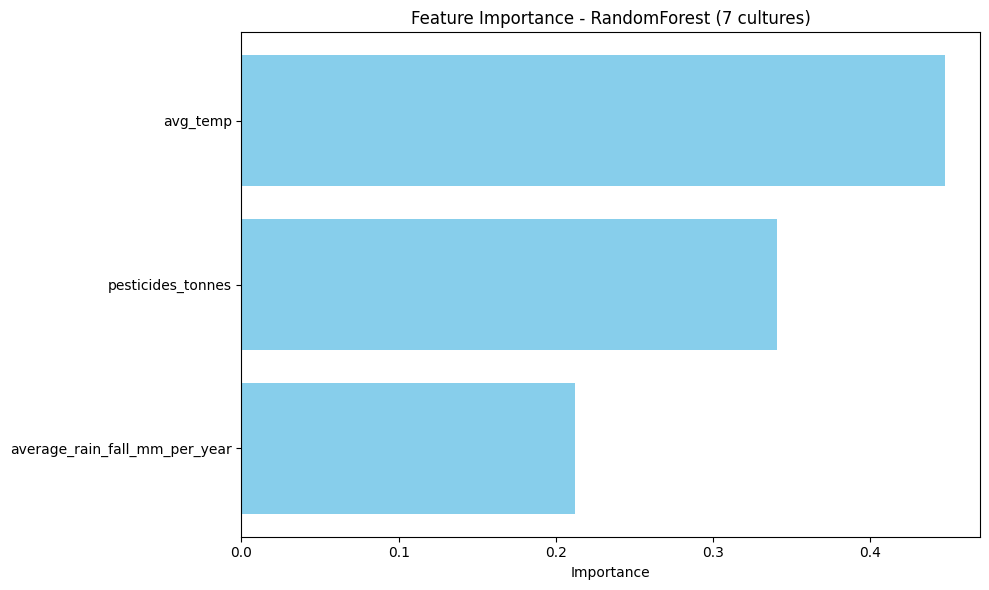

In [52]:
# Graphique des Importances
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance - RandomForest (7 cultures)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

L'analyse d'importance des features révèle que :

1. **Température moyenne (45%)** : Variable la plus prédictive. 
   Chaque culture possède une plage de température optimale pour 
   son développement, expliquant cette forte contribution.

2. **Usage de pesticides (34%)** : Proxy de l'intensité agricole 
   et de la fertilisation. Corrélation forte avec pratiques intensives.

3. **Pluviométrie (21%)** : Contribution moindre car le dataset 
   agrège à l'échelle nationale, réduisant la variabilité locale.

## Réentraînement avec Year

### Réentraînement du modèle

In [125]:
df['Item'].value_counts()

Item
Potatoes                4276
Maize                   4121
Wheat                   3857
Rice, paddy             3388
Soybeans                3223
Sorghum                 3039
Sweet potatoes          2890
Cassava                 2045
Yams                     847
Plantains and others     556
Name: count, dtype: int64

In [126]:
# Filtre des cultures retenues 
cultures_retenues = ['Maize', 'Potatoes', 'Rice, paddy', 'Soybeans', 
               'Wheat', 'Cassava', 'Sweet potatoes']

In [127]:
df_final = df[df['Item'].isin(cultures_retenues)].copy()
le = LabelEncoder()
df_final['Item_encoded'] = le.fit_transform(df_final['Item'])

In [128]:
df_final.columns.tolist()

['Area',
 'Area_Code',
 'Item',
 'Year',
 'yield_hg_per_ha',
 'average_rain_fall_mm_per_year',
 'pesticides_tonnes',
 'avg_temp_old',
 'avg_temp',
 'Fertilizer_proxy',
 'Irrigation_proxy',
 'Cluster_climat',
 'Cluster_label',
 'Item_encoded']

In [129]:
print(f"Nombre de lignes dans df_final : {len(df_final)}")
print(f"Cultures dans df_final : {df_final['Item'].unique()}")
print(f"Nombre de cultures : {df_final['Item'].nunique()}")

Nombre de lignes dans df_final : 23800
Cultures dans df_final : ['Maize' 'Potatoes' 'Rice, paddy' 'Soybeans' 'Wheat' 'Cassava'
 'Sweet potatoes']
Nombre de cultures : 7


In [130]:
# Comparaison
print(f"\nNombre total dans df (toutes cultures) : {len(df)}")
print(f"Nombre après filtrage 7 cultures : {len(df[df['Item'].isin(cultures_retenues)])}")


Nombre total dans df (toutes cultures) : 28242
Nombre après filtrage 7 cultures : 23800


In [131]:
# Feature + target 
X = df_final[['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'Year', 'Item_encoded']]
y = df_final['yield_hg_per_ha']

In [132]:
X.columns

Index(['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp',
       'Year', 'Item_encoded'],
      dtype='object')

In [133]:
# Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [134]:
# Vérifications 
X_train.shape

(19040, 5)

In [135]:
X_train['Year'].min()

np.int64(1990)

In [136]:
X_train['Year'].max()

np.int64(2013)

In [137]:
print("AVANT standardisation :")
print(X_train[['Year', 'avg_temp', 'pesticides_tonnes', 'average_rain_fall_mm_per_year', 'Item_encoded']].describe())

AVANT standardisation :
               Year      avg_temp  pesticides_tonnes  \
count  19040.000000  19040.000000       19040.000000   
mean    2001.532038     20.314450       36640.356394   
std        7.042100      6.078729       58105.337768   
min     1990.000000      1.300000           0.040000   
25%     1995.000000     16.450000        1836.210000   
50%     2001.000000     21.590000       18849.000000   
75%     2008.000000     25.630000       48618.460000   
max     2013.000000     30.420000      367778.000000   

       average_rain_fall_mm_per_year  Item_encoded  
count                   19040.000000  19040.000000  
mean                     1133.924212      3.077731  
std                       702.262972      1.930335  
min                        51.000000      0.000000  
25%                       591.000000      1.000000  
50%                      1083.000000      3.000000  
75%                      1668.000000      5.000000  
max                      3240.000000      6.000

In [138]:
# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [140]:
# Entraîner RandomForest sur TOUTES les cultures
model_with_year = RandomForestRegressor(random_state=RANDOM_STATE)
model_with_year.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [141]:
y_pred_train = model_with_year.predict(X_train_scaled)
y_pred_test = model_with_year.predict(X_test_scaled)

In [144]:
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
ecart = r2_train - r2_test

In [145]:
print(f"  R² train: {r2_train:.3f}")
print(f"  R² test:  {r2_test:.3f}")
print(f"  Écart:    {ecart:.3f} {'✅' if ecart < 0.05 else '⚠️' if ecart < 0.15 else '🔴'}")

  R² train: 0.998
  R² test:  0.983
  Écart:    0.015 ✅


### Feature Importance avec Year

In [146]:
# Extraire importances
importances = model_with_year.feature_importances_

# Créer DataFrame
feature_names = ['Rainfall', 'Pesticides', 'Temperature', 'Year', 'Culture']
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feature_imp_df)

       Feature  Importance
4      Culture    0.602396
2  Temperature    0.167087
1   Pesticides    0.113566
0     Rainfall    0.087079
3         Year    0.029872


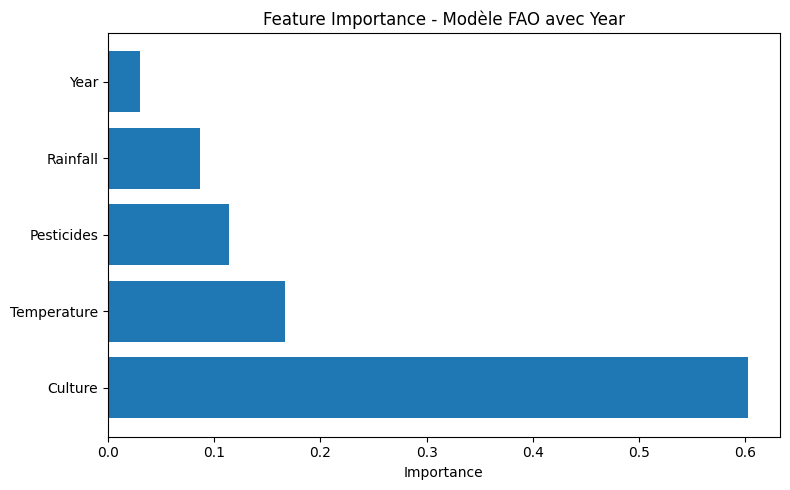

In [148]:
# Graphique + sauvegarde
plt.figure(figsize=(8,5))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Modèle FAO avec Year')
plt.tight_layout()
plt.show()

## Tests et décision prédiction hybride FAO + données historiques

Lors de l'analyse du dataset historique, nous avons testé une régression linéaire avec les features suivantes :
- Fertilizer_Used
- Irrigation_Used
- Soil_Type
- Rainfall_mm
- Temperature_Celsius

Ce modèle donne des résultats encourageants (R²~0.91) :

📊 CIBLE : RENDEMENT (Yield_tons_per_hectare)
Culture       R²      MAE     RMSE
 Cotton 0.910951 0.399446 0.501382
   Rice 0.913413 0.398746 0.499309
 Barley 0.913894 0.398356 0.498633
Soybean 0.913612 0.397215 0.498645
  Wheat 0.914183 0.395153 0.495741
  Maize 0.913011 0.398964 0.499508

L'idée est de proposer une **personnalisation** du rendement à l'agriculteur, qui, en plus du pays, pourra, en fonction du sol de sa parcelle, de son usage ou non de fertilisants et de l'irrigation, obtenir soit une prédiction de rendement (mode /predict), soit une recommandation de culture (mode /recommend).

**Note importante :** Ce modèle ne fera des propositions que pour les cultures présentes dans les 2 datasets :
- Wheat
- Maize
- Rice
- Soybeans

Le modèle historique sera appliqué uniquement si les conditions climatiques du pays (pluviométrie ±100mm, température ±3°C) correspondent aux données disponibles dans l'historique.

### Chargement du dataset et filtrage sur cultures communes

In [150]:
df_historiques = pd.read_csv(DONNEES_HISTORIQUES / "crop_yield_clean.csv")

In [151]:
df_historiques.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,110,7.248251


In [160]:
df_historiques.shape

(999708, 9)

In [152]:
df_historiques['Crop'].unique()

array(['Cotton', 'Rice', 'Barley', 'Soybean', 'Wheat', 'Maize'],
      dtype=object)

In [153]:
cultures_historiques_conservees = ['Wheat', 'Maize', 'Rice', 'Soybean']

In [158]:
df_historiques_personnalisation = df_historiques[df_historiques['Crop'].isin(cultures_historiques_conservees)].copy()

In [159]:
df_historiques_personnalisation.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare
1,South,Clay,Rice,992.673282,18.026142,True,True,140,8.527341
3,North,Sandy,Soybean,986.866331,16.644190,False,True,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,110,7.248251
5,South,Silt,Soybean,797.471182,37.704974,False,True,74,5.898416
6,West,Clay,Wheat,357.902357,31.593431,False,False,90,2.652392


In [162]:
df_historiques_personnalisation.info()

<class 'pandas.core.frame.DataFrame'>
Index: 666455 entries, 1 to 999707
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Region                  666455 non-null  object 
 1   Soil_Type               666455 non-null  object 
 2   Crop                    666455 non-null  object 
 3   Rainfall_mm             666455 non-null  float64
 4   Temperature_Celsius     666455 non-null  float64
 5   Fertilizer_Used         666455 non-null  bool   
 6   Irrigation_Used         666455 non-null  bool   
 7   Days_to_Harvest         666455 non-null  int64  
 8   Yield_tons_per_hectare  666455 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(3)
memory usage: 41.9+ MB


In [161]:
df_historiques_personnalisation.shape

(666455, 9)

### Entraînement RandomForest Historique

In [166]:
def analyser_combinaisons_culture(df, crop_name, target_column='Yield_tons_per_hectare'):
    """
    Analyse combinaisons Fert × Irrig × Soil pour une culture
    
    Paramètres :
    - df : DataFrame historique
    - crop_name : Nom de la culture
    - target_column : Variable cible ('Yield_tons_per_hectare' ou 'Days_to_Harvest')
    
    Retourne : dict avec métriques (R², MAE, RMSE)
    """
    df = df[df['Crop'] == crop_name].copy()  # ← AJOUT .copy()
    # 2. Encoder booléens en binaire
    df['Fertilizer_Used'] = df['Fertilizer_Used'].astype(int)
    df['Irrigation_Used'] = df['Irrigation_Used'].astype(int)
    
    # 3. Encoder Soil_Type
    soil_mapping = {
        'Sandy': 0, 'Clay': 1, 'Loam': 2,
        'Chalky': 3, 'Silt': 4, 'Peaty': 5
    }
    df['Soil_Encoded'] = df['Soil_Type'].map(soil_mapping)
    
    # 4. Features + Target
    X = df[['Fertilizer_Used', 'Irrigation_Used', 'Soil_Encoded', 
                 'Rainfall_mm', 'Temperature_Celsius']].astype(float)
    y = df[target_column]
    
    # 5. Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )
    
    # 6. Modèle
    model = RandomForestRegressor(n_estimators=50,
                                   max_depth=20,
                                  n_jobs=-1,
                                  random_state=RANDOM_STATE
                                 )
    # Je n'ai pas standardisé
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # 7. Métriques
    return {
        'Culture': crop_name,
        'Target': target_column,
        'R²': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    }

In [167]:
# Analyser les 2 cibles pour les 6 cultures
cultures = df_historiques_personnalisation['Crop'].unique()
resultats_yield = []
resultats_days = []

print("=== ANALYSE DES DEUX CIBLES ===\n")

# Cible 1 : Yield
print("📊 CIBLE 1 : RENDEMENT (Yield_tons_per_hectare)")
for crop in cultures:
    metrics = analyser_combinaisons_culture(df_historiques_personnalisation, crop, 'Yield_tons_per_hectare')
    resultats_yield.append(metrics)

df_yield = pd.DataFrame(resultats_yield)
print(df_yield[['Culture', 'R²', 'MAE', 'RMSE']].to_string(index=False))

# Cible 2 : Days_to_Harvest
print("\n⏱️ CIBLE 2 : DURÉE DE CROISSANCE (Days_to_Harvest)")
for crop in cultures:
    metrics = analyser_combinaisons_culture(df_historiques_personnalisation, crop, 'Days_to_Harvest')
    resultats_days.append(metrics)

df_days = pd.DataFrame(resultats_days)
print(df_days[['Culture', 'R²', 'MAE', 'RMSE']].to_string(index=False))

=== ANALYSE DES DEUX CIBLES ===

📊 CIBLE 1 : RENDEMENT (Yield_tons_per_hectare)
Culture       R²      MAE     RMSE
   Rice 0.903770 0.420134 0.526380
Soybean 0.903446 0.419528 0.527171
  Wheat 0.903608 0.418901 0.525399
  Maize 0.903189 0.420785 0.526953

⏱️ CIBLE 2 : DURÉE DE CROISSANCE (Days_to_Harvest)
Culture        R²       MAE      RMSE
   Rice -0.005130 22.440283 25.936033
Soybean -0.006339 22.486725 26.002668
  Wheat -0.006189 22.562045 26.078873
  Maize -0.006995 22.547412 26.068217


### Fonction matching Rainfall/Temp

In [178]:
# Vérifier unicité Rainfall par pays ‼️A insérer dans EDA FAO
check_rainfall = df.groupby('Area')['average_rain_fall_mm_per_year'].nunique()

print("Nombre de valeurs distinctes de Rainfall par pays :")
print(check_rainfall.describe())
print(f"\nPays avec >1 valeur Rainfall : {(check_rainfall > 1).sum()}")

# Si >1, voir lesquels
if (check_rainfall > 1).any():
    pays_multiples = check_rainfall[check_rainfall > 1]
    print(f"\nPays concernés :\n{pays_multiples}")

Nombre de valeurs distinctes de Rainfall par pays :
count    101.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: average_rain_fall_mm_per_year, dtype: float64

Pays avec >1 valeur Rainfall : 0


**TODO - Refactoring EDA FAO :**
- Vérifier systématiquement l'unicité de `average_rain_fall_mm_per_year` par pays
- Documenter si valeur fixe ou variable temporelle
- Si variable : analyser variance et décider agrégation (mean/median/last)
- Ajouter dans section "Validation qualité données"

In [179]:
# Lookup table pays
lookup_pays = df.groupby('Area').agg({
    'average_rain_fall_mm_per_year': 'first',  # ✅ Fixe
    'avg_temp': 'mean'  # ✅ Moyenne temporelle
}).reset_index()

lookup_pays.columns = ['Country', 'Rainfall_mm', 'Temp_C']

In [180]:
lookup_pays.head()

,Country,Rainfall_mm,Temp_C
0,Albania,1485.0,16.300101
1,Algeria,89.0,17.484825
2,Angola,1010.0,24.311341
3,Argentina,591.0,17.530870
4,Armenia,562.0,9.580952


In [181]:
# Compter combinaisons uniques
n_combinations = df_historiques_personnalisation.groupby([
    'Crop', 'Soil_Type', 'Fertilizer_Used', 'Irrigation_Used'
]).size().reset_index(name='Count')

print(f"Nombre de combinaisons uniques : {len(n_combinations)}")
print(f"Total lignes : {len(df_historiques_personnalisation)}")
print(f"\nDistribution counts par combinaison :")
print(n_combinations['Count'].describe())

# Si Count = constant → CATALOGUE
# Si Count variable → Observations réelles

Nombre de combinaisons uniques : 96
Total lignes : 666455

Distribution counts par combinaison :
count      96.000000
mean     6942.239583
std        80.965587
min      6734.000000
25%      6895.000000
50%      6930.000000
75%      7000.000000
max      7138.000000
Name: Count, dtype: float64


## Stratégie finale suite aux différents tests et analyses

### Contexte et découverte clé

Le dataset historique est un **catalogue combinatoire** (96 combinaisons × ~7000 observations chacune) et non des données observées réelles. Cette structure SERVIRA comme **base de données de référence** pour affiner les prédictions FAO selon les pratiques agricoles parcellaires.

**Preuve :** Distribution quasi-uniforme des observations par combinaison (moyenne = 6,942 lignes, écart-type = 81), démontrant une génération synthétique systématique.

---

### Architecture globale du système hybride

#### Dataset FAO (Baseline nationale)
- **Granularité :** Pays × Culture × Année
- **Features :** Rainfall (mm), Temperature (°C), Pesticides (tonnes), Year, Culture encodée
- **Modèle :** RandomForest (R² = 0.983, n_estimators=100)
- **Cultures couvertes :** 7 cultures représentant 84.3% du dataset (23,800/28,242 obs)
  - Cassava (R²=0.976), Potatoes (R²=0.955), Wheat (R²=0.952), Rice (R²=0.946)
  - Soybeans (R²=0.944), Sweet potatoes (R²=0.927), Maize (R²=0.923)
- **Output :** Rendement moyen national selon climat du pays

#### Dataset Historique (Ajustement pratiques)
- **Granularité :** Parcelle synthétique
- **Features :** Soil_Type, Fertilizer_Used (O/N), Irrigation_Used (O/N), Rainfall (mm), Temperature (°C)
- **Utilisation :** Requête SQL-like directe sur catalogue (pas de modèle ML)
- **Performance catalogue :** R² = 0.90 pour les 4 cultures (RandomForest validation)
- **Cultures couvertes :** 4 cultures communes avec FAO (Wheat, Maize, Rice, Soybean)
- **Output :** Rendement personnalisé selon pratiques parcellaires

**Note importante :** Aucun rapprochement proxy entre FAO et Historique n'est possible. Les tests de proxys binaires (Fertilizer_proxy basé sur pesticides, Irrigation_proxy basé sur rainfall) ont donné R²=0.23 contre R²=0.946 avec variables continues. Les deux datasets opèrent à des échelles différentes (nationale vs parcellaire) et sont strictement complémentaires, non substituables.

---

### MODE 1 : Prédiction de rendement

#### Inputs utilisateur
```
- Pays (obligatoire)
- Culture (obligatoire) - parmi les 7 disponibles
- Type de sol (Sandy, Clay, Loam, Chalky, Silt, Peaty)
- Utilisation fertilisants (Oui/Non)
- Système irrigation (Oui/Non)
```

#### Pipeline d'exécution

**ÉTAPE 1 - Baseline FAO (toujours exécutée)**
```
1. Lookup pays → Rainfall_pays, Temp_pays (moyenne 1990-2013), Pesticides_pays
2. Modèle FAO.predict(Rainfall, Temp, Pesticides, Year=2026, Culture_encoded)
3. Output: yield_fao (baseline nationale en hg/ha)
```

**ÉTAPE 2 - Ajustement Historique (conditionnel)**

**SI** Culture ∈ {Wheat, Maize, Rice, Soybean} **ALORS :**
```
1. Requête sur catalogue historique avec filtres :
   - Crop = Culture
   - Soil_Type = Sol_utilisateur
   - Fertilizer_Used = Fert_utilisateur
   - Irrigation_Used = Irrig_utilisateur
   - Rainfall_mm ∈ [Rainfall_pays - 100, Rainfall_pays + 100]
   - Temperature_Celsius ∈ [Temp_pays - 3, Temp_pays + 3]

2. SI nombre_lignes_matchées ≥ 50 :
   - yield_hist = moyenne(Yield_tons_per_hectare des lignes matchées)
   - ajustement_pct = ((yield_hist - yield_fao_tonnes) / yield_fao_tonnes) × 100
   - Output: yield_hist, ajustement_pct, n_observations
   
3. SINON :
   - Message: "Conditions climatiques hors catalogue (< 50 observations similaires)"
   - Output: yield_fao uniquement
```

**SINON** (Culture ∈ {Cassava, Potatoes, Sweet potatoes}) :
```
- Output: yield_fao uniquement
- Message: "Culture non disponible dans le catalogue historique"
```

#### Format de sortie

**Cas 1 - Avec ajustement disponible :**
```
📊 RENDEMENT ESTIMÉ : 6.8 tonnes/ha

Détails :
├─ Baseline climat pays (FAO) : 6.2 tonnes/ha
│  (France, Wheat, climat moyen 1990-2013)
│
└─ Ajustement pratiques parcellaires : +0.6 t/ha (+10%)
   (Sol Clay, Fertilisants Oui, Irrigation Oui)
   
⚠️ Basé sur 1,847 parcelles similaires du catalogue
```

**Cas 2 - Sans ajustement :**
```
📊 RENDEMENT ESTIMÉ : 6.2 tonnes/ha

Baseline climat pays (FAO)
(France, Potatoes, climat moyen 1990-2013)

ℹ️ Culture non disponible dans le catalogue historique
   OU
ℹ️ Conditions climatiques hors catalogue (< 50 observations similaires)
```

---

### MODE 2 : Recommandation de culture

#### Inputs utilisateur
```
- Pays (obligatoire)
- Type de sol (Sandy, Clay, Loam, Chalky, Silt, Peaty)
- Utilisation fertilisants (Oui/Non)
- Système irrigation (Oui/Non)
```

#### Pipeline d'exécution

**ÉTAPE 1 - Prédictions FAO (7 cultures)**
```
1. Lookup pays → Rainfall_pays, Temp_pays (moyenne 1990-2013), Pesticides_pays
2. POUR chaque culture in [Maize, Potatoes, Rice, Soybeans, Wheat, Cassava, Sweet potatoes] :
   - yield_fao[culture] = Modèle FAO.predict(Rainfall, Temp, Pesticides, Year=2026, Culture)
3. Créer DataFrame : [Culture, Yield_FAO_tonnes]
```

**ÉTAPE 2 - Ajustements Historique (4 cultures communes)**
```
POUR chaque culture in [Wheat, Maize, Rice, Soybean] :
   1. Requête catalogue historique (même filtres que Mode 1)
   2. SI matches ≥ 50 :
      - yield_hist[culture] = moyenne(lignes matchées)
      - ajustement[culture] = yield_hist - yield_fao
   3. SINON :
      - yield_final[culture] = yield_fao (pas d'ajustement)
```

**ÉTAPE 3 - Classement final**
```
1. Trier cultures par yield_final décroissant
2. Retourner liste ordonnée avec colonnes :
   - Rang
   - Culture
   - Yield_FAO (baseline)
   - Yield_Ajusté (si disponible)
   - Ajustement_% (si disponible)
   - N_observations_matchées
```

#### Format de sortie
```
📊 CULTURES RECOMMANDÉES POUR VOTRE PARCELLE

Pays : France
Sol : Clay | Fertilisants : Oui | Irrigation : Oui

┌─────┬─────────────────┬──────────────┬────────────────┬─────────────┐
│ Rg  │ Culture         │ Baseline FAO │ Rendement Final│ Ajustement  │
├─────┼─────────────────┼──────────────┼────────────────┼─────────────┤
│ 1   │ Potatoes        │ 28.5 t/ha    │ 28.5 t/ha      │ -           │
│ 2   │ Wheat *         │ 6.2 t/ha     │ 6.8 t/ha       │ +10% (1,847)│
│ 3   │ Maize *         │ 9.1 t/ha     │ 9.4 t/ha       │ +3% (2,103) │
│ 4   │ Rice *          │ 5.8 t/ha     │ 5.9 t/ha       │ +2% (891)   │
│ 5   │ Cassava         │ 12.3 t/ha    │ 12.3 t/ha      │ -           │
│ 6   │ Sweet potatoes  │ 10.1 t/ha    │ 10.1 t/ha      │ -           │
│ 7   │ Soybean *       │ 2.8 t/ha     │ 2.7 t/ha       │ -4% (1,234) │
└─────┴─────────────────┴──────────────┴────────────────┴─────────────┘

* Ajustement basé sur catalogue historique
```

---

### Limitations documentées

#### 1. Temporalité climatique
Les moyennes climatiques (température, pluviométrie) utilisent la période 1990-2013. Le réchauffement climatique post-2013 n'est pas capturé. Pour prédictions 2026 (13 ans d'extrapolation), incertitude accrue sur température (+0.2-0.3°C attendu selon GIEC). La tolérance matching élargie (±3°C) compense partiellement cette limitation. 

**Source :** FAO (2022) rapporte gains rendements céréales +19% à +33% sur 2000-2020, confirmant les tendances temporelles observées dans nos données (+0.73% à +2.56%/an selon culture).

#### 2. Granularité spatiale
Le modèle FAO agrège au niveau national, masquant la variabilité régionale intra-pays importante (facteur ×4 entre régions pour le maïs selon FAO 2022). Le dataset historique compense partiellement via l'ajustement sol et pratiques, mais ne capture pas les microclimats locaux ni les disparités géographiques infranationales.

#### 3. Dataset historique synthétique
Le catalogue historique est généré synthétiquement (96 combinaisons × ~7000 observations, distribution quasi-uniforme validée). Bien que les relations agronomiques soient cohérentes (R²=0.90 en validation RandomForest), il ne reflète pas de parcelles réelles observées. Les ajustements proposés sont des tendances moyennes statistiques, pas des garanties de rendement individuel.

#### 4. Pesticides non personnalisables
La variable `pesticides_tonnes` du modèle FAO est agrégée au niveau national (ex: France = 50,000 tonnes/an). L'agriculteur ne peut pas personnaliser son usage individuel de pesticides dans la prédiction FAO. Seules les pratiques fertilisation/irrigation sont personnalisables via le catalogue historique pour les 4 cultures communes.

#### 5. Variable Year et extrapolation 2026
La variable `Year` capture les progrès agricoles documentés (+0.73% à +2.56%/an selon culture, R²>0.95, p<0.001). L'extrapolation linéaire sur 13 ans supplémentaires (2013→2026) comporte des incertitudes : ralentissement documenté des gains de productivité, plafonds agronomiques, impacts non linéaires du changement climatique. Les prédictions 2026 constituent des estimations hautes avec intervalle de confiance élargi.

---

### Interface Streamlit - Messages contextuels

**Mode Prédiction :**
> ℹ️ **Personnalisation disponible :** Si votre culture est Wheat, Maize, Rice ou Soybean, le système vous proposera une estimation personnalisée basée sur votre type de sol et vos pratiques agricoles (fertilisation, irrigation), en plus de la baseline climatique nationale.

**Mode Recommandation :**
> ℹ️ **Lecture du tableau :** Les cultures marquées d'un astérisque (*) bénéficient d'un ajustement personnalisé selon votre sol et vos pratiques. Les autres cultures affichent uniquement la baseline climatique nationale FAO. Le nombre entre parenthèses indique le nombre de parcelles similaires trouvées dans le catalogue.

**Message d'avertissement général :**
> ⚠️ **Avertissement :** Ces prédictions sont des estimations statistiques basées sur des moyennes climatiques 1990-2013 et un catalogue synthétique. Elles ne constituent pas une garantie de rendement réel, qui dépend de nombreux facteurs non modélisés (variété semence, pratiques culturales spécifiques, événements climatiques extrêmes, maladies, ravageurs, etc.).